<a href="https://colab.research.google.com/github/ginasoft/vision-computacional/blob/main/Clase06_Actividad_Basica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Habilita el eje Z (profundidad)

In [4]:
imagen_bgr = cv2.imread("gata.jpg")
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
alto, ancho, _ = imagen_rgb.shape

colores = imagen_rgb / 255.0  # Normalizamos a [0,1] para facecolors

In [5]:
x, y = np.meshgrid(np.arange(ancho), np.arange(alto))
z = np.zeros_like(x)  # Imagen plana en el origen Z=0
w = np.ones_like(x)   # Coordenada homogénea

In [6]:
# [x, y, z, 1]
puntos = np.vstack([x.flatten(), y.flatten(), z.flatten(), w.flatten()])

In [7]:
# 1) ESCALADO: reducir a la mitad
s = 0.5
H_esc = np.array([
    [s, 0, 0, 0],   # escala X
    [0, s, 0, 0],   # escala Y
    [0, 0, s, 0],   # escala Z
    [0, 0, 0, 1]
])

# 2) ROTACION: 45 grados respecto al eje Y (afecta X y Z, deja Y intacto)
theta = np.deg2rad(45)
H_rot = np.array([
    [ np.cos(theta), 0, np.sin(theta), 0],   # Nueva X depende de X y Z
    [ 0,             1, 0,             0],   # Y no se modifica
    [-np.sin(theta), 0, np.cos(theta), 0],   # Nueva Z depende de X y Z
    [ 0,             0, 0,             1]
])

# 3) TRASLACION: elevar a Z=15 y desplazar 200 en X
tx, ty, tz = 200, 0, 15
H_tras = np.array([
    [1, 0, 0, tx],
    [0, 1, 0, ty],
    [0, 0, 1, tz],
    [0, 0, 0, 1]
])

In [8]:
# Orden de aplicacion: primero escala, luego rota, despues traslada.
# Como es M' = H @ M (mapeo directo), la matriz que actua ULTIMO va a la IZQUIERDA.
H = H_tras @ H_rot @ H_esc

In [9]:
puntos_transformados = H @ puntos

In [10]:
x_new = puntos_transformados[0, :].reshape(alto, ancho)
y_new = puntos_transformados[1, :].reshape(alto, ancho)
z_new = puntos_transformados[2, :].reshape(alto, ancho)

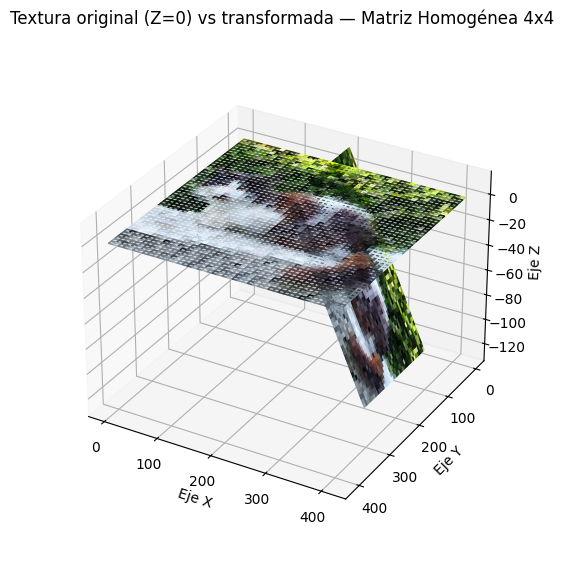

In [11]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Imagen ORIGINAL en el suelo Z=0 con transparencia 0.3
ax.plot_surface(x, y, z, facecolors=colores, shade=False, alpha=0.3)

# Imagen TRANSFORMADA en su nueva posicion
ax.plot_surface(x_new, y_new, z_new, facecolors=colores, shade=False)

ax.set_xlabel('Eje X')
ax.set_ylabel('Eje Y')
ax.set_zlabel('Eje Z')
ax.set_box_aspect(None, zoom=0.85)
ax.set_title("Textura original (Z=0) vs transformada — Matriz Homogénea 4x4")
ax.invert_yaxis()  # Si no invertimos Y, la gata aparece patas arriba
plt.show()